# Group 2: Training Data Processing, Clustering & Cluster-ID Model
**CS 559: Machine Learning**

**Company Bankruptcy Prediction**

**Team Members:** Aidan Nestor, Andrey Baklykov, Noah Miller, Sanjavan Ghodasara

This notebook covers:
- **Section 3.1**: Training Data Preprocessing
- **Section 3.2**: Company Characterization (Clustering)
- **Section 3.3.1**: Cluster-ID Prediction Model

---
## Section 3.1 Training Data Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
CLUSTER_DIR = os.path.join(DATA_DIR, 'clusters')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')

print(f'Project directory: {PROJECT_DIR}')

Project directory: /Users/noahmiller/Documents/CS/CS-559/Project


### 3.1.1 Load & Inspect/Explore Data

In [2]:
# Load training data
df = pd.read_csv(os.path.join(DATA_DIR, 'train_data.csv'))

# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
print(f'Columns: {len(df.columns)}')
print(f'\nTarget distribution:')
print(df['Bankrupt?'].value_counts())
print(f'\nBankruptcy rate: {df["Bankrupt?"].mean():.4f} ({df["Bankrupt?"].sum()} / {len(df)})')

Shape: (5807, 97)
Columns: 97

Target distribution:
Bankrupt?
0    5609
1     198
Name: count, dtype: int64

Bankruptcy rate: 0.0341 (198 / 5807)


In [3]:
# Check for missing values and data types
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values')
print(f'\nTotal missing: {missing.sum()}')
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'\nData types:\n{df.dtypes.value_counts()}')

Missing values per column:
No missing values

Total missing: 0

Duplicates: 0

Data types:
float64    93
int64       4
Name: count, dtype: int64


In [4]:
# Separate target and features
y_train = df['Bankrupt?'].copy()
df_index = df['Index'].copy()

# Drop Index and Bankrupt? for feature analysis
feature_cols = [c for c in df.columns if c not in ['Index', 'Bankrupt?']]
X_raw = df[feature_cols].copy()

print(f'Number of features: {len(feature_cols)}')
print(f'Feature matrix shape: {X_raw.shape}')

Number of features: 95
Feature matrix shape: (5807, 95)


In [5]:
# Summary statistics
X_raw.describe().T.sort_values('std', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
Quick Asset Turnover Rate,5807.0,2.155687e+09,3.376215e+09,0.000100,1.409700e-04,2.233270e-04,4.875000e+09,1.000000e+10
Operating Expense Rate,5807.0,1.997255e+09,3.238387e+09,0.000000,1.559360e-04,2.772960e-04,4.190000e+09,9.990000e+09
Inventory Turnover Rate (times),5807.0,2.125190e+09,3.235523e+09,0.000000,1.724435e-04,7.205360e-04,4.570000e+09,9.990000e+09
Cash Turnover Rate,5807.0,2.487315e+09,2.963376e+09,0.000000,2.738165e-04,1.050000e+09,4.550000e+09,1.000000e+10
Total Asset Growth Rate,5807.0,5.496935e+09,2.908731e+09,0.000100,4.850000e+09,6.400000e+09,7.390000e+09,9.990000e+09
Current Asset Turnover Rate,5807.0,1.185723e+09,2.809907e+09,0.000000,1.455370e-04,1.982660e-04,4.466770e-04,1.000000e+10
Research and development expense rate,5807.0,1.983664e+09,2.614123e+09,0.000000,1.298860e-04,5.430000e+08,3.510000e+09,9.980000e+09
Fixed Assets Turnover Frequency,5807.0,1.012364e+09,2.476336e+09,0.000000,2.341360e-04,6.021720e-04,3.759037e-03,9.990000e+09
Inventory/Current Liability,5807.0,5.630232e+07,5.869665e+08,0.000000,3.124289e-03,6.467281e-03,1.104760e-02,9.910000e+09
Long-term Liability to Current Assets,5807.0,5.028395e+07,5.435874e+08,0.000000,0.000000e+00,2.015049e-03,8.990959e-03,9.540000e+09


### 3.1.2 Investigate Outliers or Potentially Bad Data

After browsing the data it appears some features contain very large values (e.g., > 1e9) which appear anomalous compared to the typical [0,1] range of most financial ratios. We need to identify and handle these.

In [6]:
# Identify columns with extreme outlier values
# Most features are ratios in [0,1]; values > 10 are suspicious
suspicious_threshold = 10
suspicious_counts = (X_raw > suspicious_threshold).sum()
suspicious_cols = suspicious_counts[suspicious_counts > 0].sort_values(ascending=False)

print(f'Columns with values > {suspicious_threshold}:')
print(suspicious_cols)
print(f'\nTotal columns with suspicious values: {len(suspicious_cols)}')

Columns with values > 10:
Total Asset Growth Rate                  5112
Cash Turnover Rate                       3604
Research and development expense rate    3464
Inventory Turnover Rate (times)          2482
Quick Asset Turnover Rate                2020
Operating Expense Rate                   1947
Fixed Assets Turnover Frequency          1058
Current Asset Turnover Rate              1053
Interest-bearing debt interest rate       186
Long-term Liability to Current Assets      89
Inventory/Current Liability                85
Cash/Current Liability                     40
Accounts Receivable Turnover               19
Total assets to GNP price                  16
Average Collection Days                    14
Allocation rate per person                 12
Quick Ratio                                 7
Total debt/Total net worth                  7
Revenue Per Share (Yuan ¥)                  3
Net Value Growth Rate                       2
Quick Assets/Current Liability              2
Revenue 

In [32]:
# For columns with extreme outliers, clip to reasonable percentile range
# This handles the parsing artifacts (values like 6.27e9 in ratio columns)
for col in X_raw.columns:
    q01 = X_raw[col].quantile(0.01)
    q99 = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(lower=q01, upper=q99)

print('Outliers clipped to [1st, 99th] percentile range.')
print(f'Max value after clipping: {X_raw.max().max():.4f}')
print(f'Min value after clipping: {X_raw.min().min():.4f}')

Outliers clipped to [1st, 99th] percentile range.
Max value after clipping: 9840000000.0000
Min value after clipping: 0.0000


### 3.1.3 — Exploratory Data Analysis

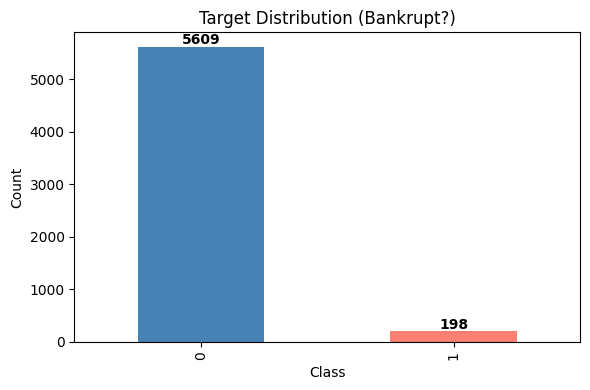

In [8]:
# Target distribution plot
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
y_train.value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Target Distribution (Bankrupt?)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for i, v in enumerate(y_train.value_counts().values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Near-zero variance features
variance = X_raw.var()
low_var_threshold = 1e-6
low_var_cols = variance[variance < low_var_threshold].index.tolist()
print(f'Features with near-zero variance (< {low_var_threshold}): {len(low_var_cols)}')
for c in low_var_cols:
    print(f'  {c}: var = {variance[c]:.2e}')

Features with near-zero variance (< 1e-06): 16
  Operating Profit Rate: var = 4.56e-08
  Pre-tax net Interest Rate: var = 1.28e-07
  After-tax net Interest Rate: var = 1.00e-07
  Non-industry income and expenditure/revenue: var = 8.20e-08
  Continuous interest rate (after tax): var = 1.04e-07
  Realized Sales Gross Profit Growth Rate: var = 1.00e-07
  Operating Profit Growth Rate: var = 2.44e-07
  Continuous Net Profit Growth Rate: var = 3.72e-08
  Net Value Growth Rate: var = 1.41e-08
  Total Asset Return Growth Rate Ratio: var = 6.77e-07
  Contingent liabilities/Net worth: var = 6.73e-07
  Total income/Total expense: var = 8.77e-08
  Working capitcal Turnover Rate: var = 9.04e-09
  Cash Flow to Sales: var = 2.00e-09
  Liability-Assets Flag: var = 0.00e+00
  Net Income Flag: var = 0.00e+00


In [10]:
# Remove near-zero variance features
X_reduced = X_raw.drop(columns=low_var_cols)
print(f'Features after removing near-zero variance: {X_reduced.shape[1]}')

Features after removing near-zero variance: 79


In [11]:
# Correlation analysis — find highly correlated pairs
corr_matrix = X_reduced.corr().abs()

# Upper triangle mask
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with |r| > 0.95
high_corr_threshold = 0.95
high_corr_pairs = []
for col in upper_tri.columns:
    correlated = upper_tri.index[upper_tri[col] > high_corr_threshold].tolist()
    for c2 in correlated:
        high_corr_pairs.append((col, c2, corr_matrix.loc[c2, col]))

print(f'Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}')
for p in high_corr_pairs[:15]:
    print(f'  {p[0][:40]:40s} <-> {p[1][:40]:40s}  r={p[2]:.4f}')
if len(high_corr_pairs) > 15:
    print(f'  ... and {len(high_corr_pairs) - 15} more')

Highly correlated pairs (|r| > 0.95): 20
  ROA(B) before interest and depreciation  <-> ROA(C) before interest and depreciation   r=0.9879
  ROA(B) before interest and depreciation  <-> ROA(A) before interest and % after tax    r=0.9559
  Realized Sales Gross Margin              <-> Operating Gross Margin                    r=0.9990
  Net Value Per Share (A)                  <-> Net Value Per Share (B)                   r=0.9998
  Net Value Per Share (C)                  <-> Net Value Per Share (B)                   r=0.9995
  Net Value Per Share (C)                  <-> Net Value Per Share (A)                   r=0.9998
  Per Share Net profit before tax (Yuan ¥) <-> Persistent EPS in the Last Four Seasons   r=0.9737
  Regular Net Profit Growth Rate           <-> After-tax Net Profit Growth Rate          r=0.9923
  Net worth/Assets                         <-> Debt ratio %                              r=1.0000
  Operating profit/Paid-in capital         <-> Operating Profit Per Share (Yu

In [12]:
# Drop one from each correlated pair (keep the one with higher correlation to target)
# Calculate correlation of each feature with target
target_corr = X_reduced.corrwith(y_train).abs()

cols_to_drop = set()
for col1, col2, _ in high_corr_pairs:
    if col1 in cols_to_drop or col2 in cols_to_drop:
        continue
    # Drop the one with lower correlation to target
    if target_corr.get(col1, 0) >= target_corr.get(col2, 0):
        cols_to_drop.add(col2)
    else:
        cols_to_drop.add(col1)

X_reduced = X_reduced.drop(columns=list(cols_to_drop))
print(f'Dropped {len(cols_to_drop)} highly correlated features')
print(f'Remaining features: {X_reduced.shape[1]}')

Dropped 16 highly correlated features
Remaining features: 63


In [13]:
# Rank remaining features by correlation with target (for reference)
target_corr_remaining = X_reduced.corrwith(y_train).abs().sort_values(ascending=False)
print('Top 20 features by |correlation| with Bankrupt?:')
for i, (feat, corr) in enumerate(target_corr_remaining.head(20).items()):
    print(f'  {i+1:2d}. {feat[:55]:55s}  |r| = {corr:.4f}')

Top 20 features by |correlation| with Bankrupt?:
   1. Net Income to Stockholder's Equity                       |r| = 0.3432
   2. Borrowing dependency                                     |r| = 0.3273
   3. Total debt/Total net worth                               |r| = 0.3094
   4. Net Income to Total Assets                               |r| = 0.2939
   5. Retained Earnings to Total Assets                        |r| = 0.2821
   6. Current Liability to Equity                              |r| = 0.2505
   7. Net worth/Assets                                         |r| = 0.2495
   8. Current Liability to Current Assets                      |r| = 0.2448
   9. Persistent EPS in the Last Four Seasons                  |r| = 0.2409
  10. Current Liability to Assets                              |r| = 0.1973
  11. Working Capital to Total Assets                          |r| = 0.1920
  12. Equity to Long-term Liability                            |r| = 0.1885
  13. Working Capital/Equity           

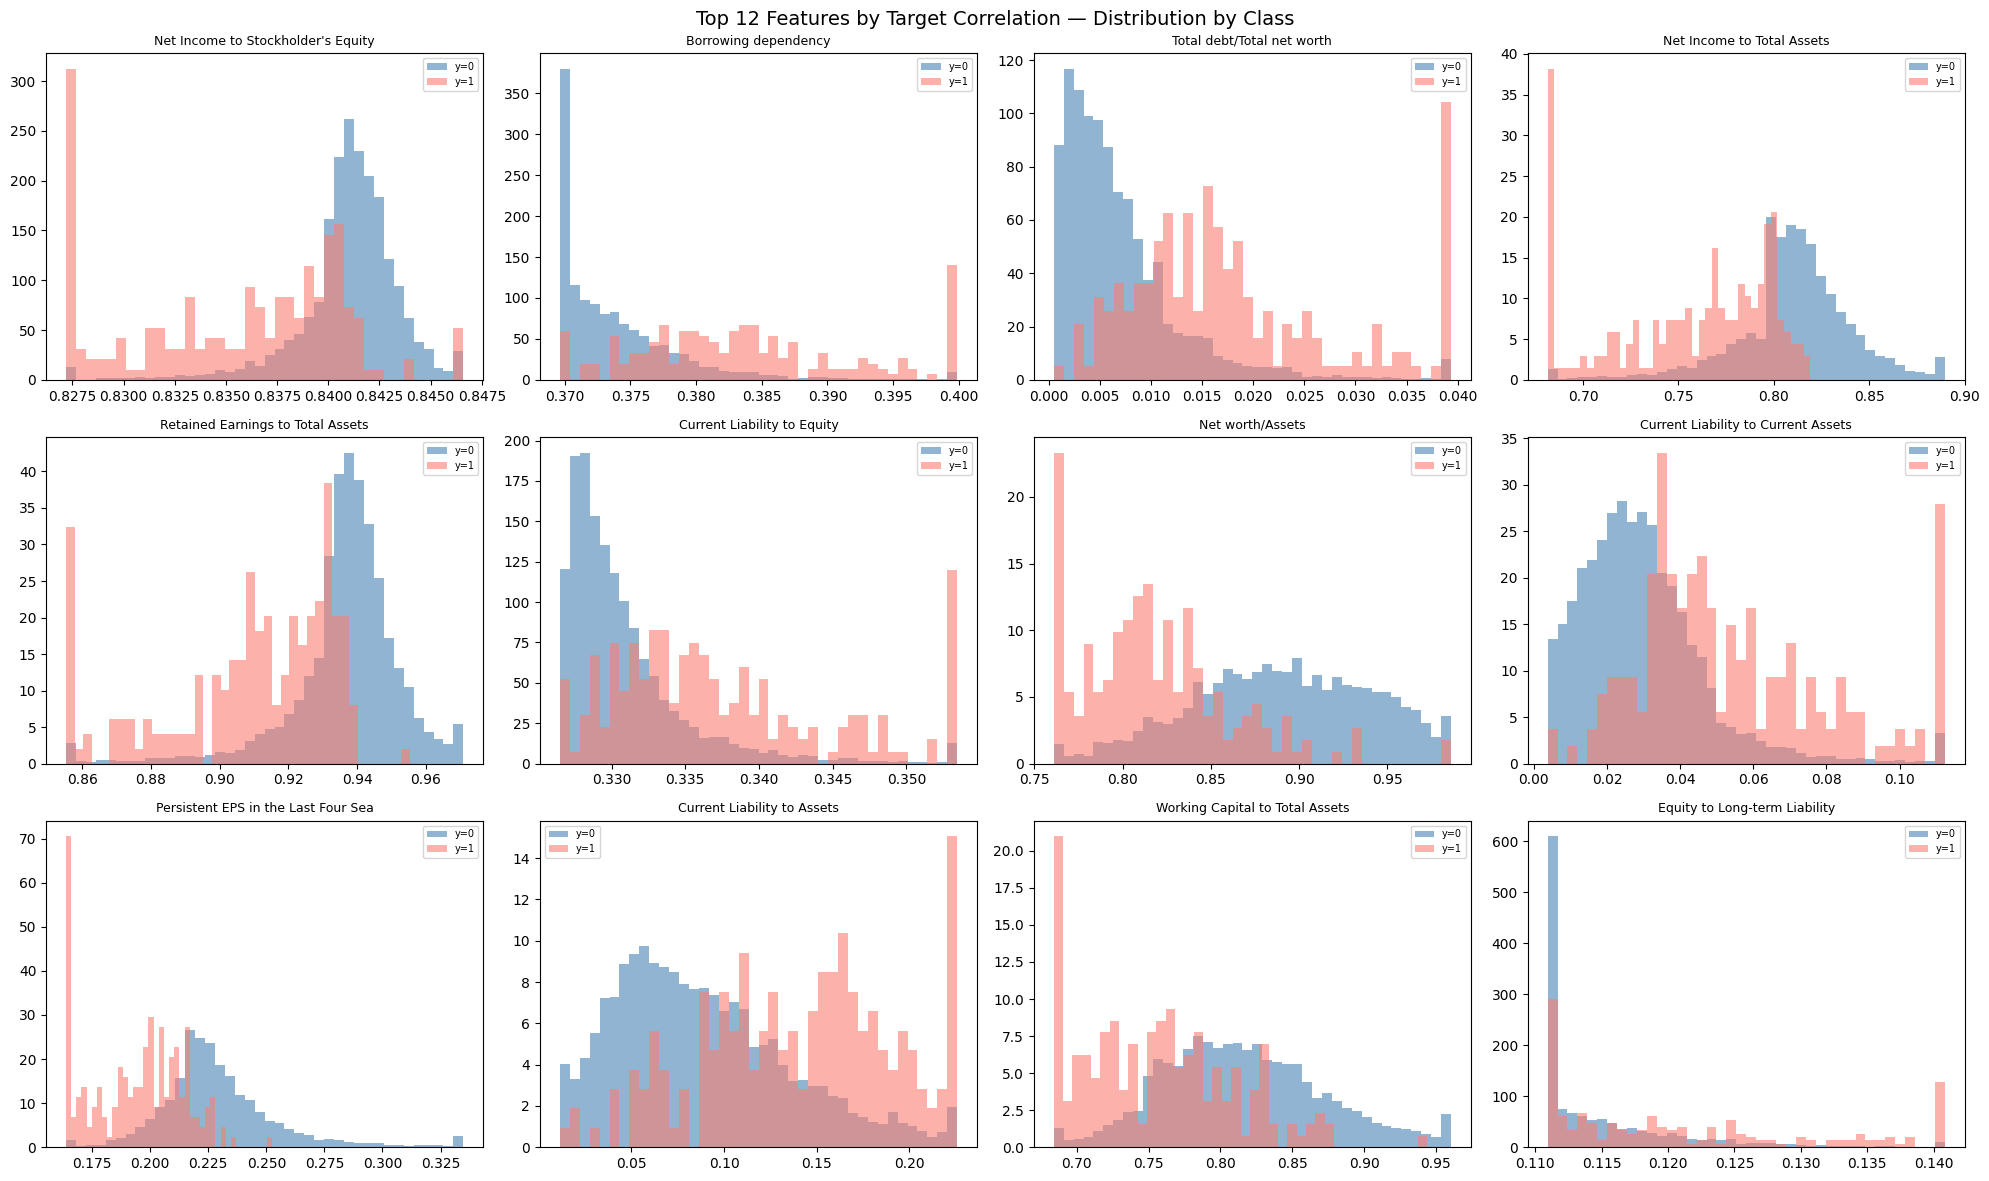

In [14]:
# Visualize top features split by bankruptcy status
top_features = target_corr_remaining.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for i, feat in enumerate(top_features):
    ax = axes[i // 4, i % 4]
    for label, color in [(0, 'steelblue'), (1, 'salmon')]:
        subset = X_reduced[y_train == label][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=f'y={label}', density=True)
    ax.set_title(feat[:35], fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle('Top 12 Features by Target Correlation — Distribution by Class', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Store the selected feature names for the clustering pipeline
clustering_features = X_reduced.columns.tolist()
print(f'\nFeatures selected for clustering: {len(clustering_features)}')
for i, f in enumerate(clustering_features):
    print(f'  {i+1:2d}. {f}')


Features selected for clustering: 63
   1. Operating Expense Rate
   2. Research and development expense rate
   3. Cash flow rate
   4. Interest-bearing debt interest rate
   5. Tax rate (A)
   6. Net Value Per Share (A)
   7. Persistent EPS in the Last Four Seasons
   8. Cash Flow Per Share
   9. Revenue Per Share (Yuan ¥)
  10. Operating Profit Per Share (Yuan ¥)
  11. Regular Net Profit Growth Rate
  12. Total Asset Growth Rate
  13. Cash Reinvestment %
  14. Current Ratio
  15. Quick Ratio
  16. Interest Expense Ratio
  17. Total debt/Total net worth
  18. Net worth/Assets
  19. Long-term fund suitability ratio (A)
  20. Borrowing dependency
  21. Inventory and accounts receivable/Net value
  22. Total Asset Turnover
  23. Accounts Receivable Turnover
  24. Average Collection Days
  25. Inventory Turnover Rate (times)
  26. Fixed Assets Turnover Frequency
  27. Net Worth Turnover Rate (times)
  28. Revenue per person
  29. Operating profit per person
  30. Allocation rate per per

### 3.1.4 — Build & Save Preprocessing Pipeline

In [34]:
class PreprocessingPipeline:
    """Reusable preprocessing pipeline that can be saved and loaded via joblib.
    Applies the same transformations to train and test data."""
    
    def __init__(self, feature_cols, low_var_cols, corr_drop_cols, clip_bounds, random_state=42):
        self.feature_cols = feature_cols
        self.low_var_cols = low_var_cols
        self.corr_drop_cols = corr_drop_cols
        self.clip_bounds = clip_bounds  
        self.scaler = StandardScaler()
        self.clustering_features = None
        self.is_fitted = False
        self.random_state = random_state
    
    def fit(self, df):
        """Fit on training data."""
        X = self._transform_raw(df)
        self.clustering_features = X.columns.tolist()
        self.scaler.fit(X)
        self.is_fitted = True
        return self
    
    def transform(self, df):
        """Transform data using fitted pipeline."""
        X = self._transform_raw(df)
        X_scaled = pd.DataFrame(
            self.scaler.transform(X),
            columns=self.clustering_features,
            index=X.index
        )
        return X_scaled
    
    def fit_transform(self, df):
        """Fit and transform in one step."""
        self.fit(df)
        return self.transform(df)
    
    def _transform_raw(self, df):
        """Apply raw transformations (before scaling)."""
        # Select only original feature columns
        cols_available = [c for c in self.feature_cols if c in df.columns]
        X = df[cols_available].copy()
        X.columns = X.columns.str.strip()
        
        # Clip outliers
        for col, (lo, hi) in self.clip_bounds.items():
            if col in X.columns:
                X[col] = X[col].clip(lower=lo, upper=hi)
        
        # Drop near-zero variance columns
        X = X.drop(columns=[c for c in self.low_var_cols if c in X.columns])
        
        # Drop highly correlated columns
        X = X.drop(columns=[c for c in self.corr_drop_cols if c in X.columns])
        
        return X

print('PreprocessingPipeline class defined.')

PreprocessingPipeline class defined.


In [17]:
# Build clip bounds from training data (before any drops)
X_raw_fresh = df[feature_cols].copy()
clip_bounds = {}
for col in X_raw_fresh.columns:
    clip_bounds[col] = (X_raw_fresh[col].quantile(0.01), X_raw_fresh[col].quantile(0.99))

# Create and fit the pipeline
pipeline = PreprocessingPipeline(
    feature_cols=feature_cols,
    low_var_cols=low_var_cols,
    corr_drop_cols=list(cols_to_drop),
    clip_bounds=clip_bounds,
    random_state=RANDOM_STATE
)

X_processed = pipeline.fit_transform(df)
print(f'Preprocessed feature matrix shape: {X_processed.shape}')
print(f'Features: {pipeline.clustering_features}')

Preprocessed feature matrix shape: (5807, 63)
Features: ['Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Interest-bearing debt interest rate', 'Tax rate (A)', 'Net Value Per Share (A)', 'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)', 'Operating Profit Per Share (Yuan ¥)', 'Regular Net Profit Growth Rate', 'Total Asset Growth Rate', 'Cash Reinvestment %', 'Current Ratio', 'Quick Ratio', 'Interest Expense Ratio', 'Total debt/Total net worth', 'Net worth/Assets', 'Long-term fund suitability ratio (A)', 'Borrowing dependency', 'Inventory and accounts receivable/Net value', 'Total Asset Turnover', 'Accounts Receivable Turnover', 'Average Collection Days', 'Inventory Turnover Rate (times)', 'Fixed Assets Turnover Frequency', 'Net Worth Turnover Rate (times)', 'Revenue per person', 'Operating profit per person', 'Allocation rate per person', 'Working Capital to Total Assets', 'Quick Assets/Total Assets', 'Cu

In [18]:
# Save preprocessing pipeline
pipeline_path = os.path.join(MODEL_DIR, 'preprocessing_pipeline.joblib')
joblib.dump(pipeline, pipeline_path)
print(f'Preprocessing pipeline saved to: {pipeline_path}')

# Verify by reloading
pipeline_loaded = joblib.load(pipeline_path)
X_verify = pipeline_loaded.transform(df)
assert np.allclose(X_processed.values, X_verify.values), 'Pipeline reload verification failed!'
print('Pipeline reload verification passed.')

Preprocessing pipeline saved to: /Users/noahmiller/Documents/CS/CS-559/Project/models/preprocessing_pipeline.joblib
Pipeline reload verification passed.


---
## Section 3.2 — Company Characterization (Clustering)

### 3.2.1 — Clustering Experiments

We try multiple clustering algorithms with k=6 and evaluate based on:
1. Silhouette score (cluster quality)
2. How well clusters separate bankrupt vs non-bankrupt companies (downstream utility)

In [36]:
K = 6  # num of clusters

def evaluate_clustering(labels, X, y):
    """Evaluate clustering quality and bankruptcy separation."""
    sil = silhouette_score(X, labels)
    results = []
    for c in sorted(set(labels)):
        mask = labels == c
        n = mask.sum()
        n_bankrupt = y[mask].sum()
        rate = n_bankrupt / n if n > 0 else 0
        results.append({'Cluster': c, 'Count': n, 'Bankrupt': int(n_bankrupt), 'Rate': rate})
    return sil, pd.DataFrame(results)

# --- KMeans ---
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20, max_iter=500)
km_labels = km.fit_predict(X_processed)
km_sil, km_df = evaluate_clustering(km_labels, X_processed, y_train)
print(f'=== KMeans (k={K}) ===')
print(f'Silhouette: {km_sil:.4f}')
print(km_df.to_string(index=False))

print()

# --- Gaussian Mixture ---
gmm = GaussianMixture(n_components=K, random_state=RANDOM_STATE, n_init=5, max_iter=500)
gmm_labels = gmm.fit_predict(X_processed)
gmm_sil, gmm_df = evaluate_clustering(gmm_labels, X_processed, y_train)
print(f'=== GMM (k={K}) ===')
print(f'Silhouette: {gmm_sil:.4f}')
print(gmm_df.to_string(index=False))

print()

# --- Agglomerative ---
agg = AgglomerativeClustering(n_clusters=K)
agg_labels = agg.fit_predict(X_processed)
agg_sil, agg_df = evaluate_clustering(agg_labels, X_processed, y_train)
print(f'=== Agglomerative (k={K}) ===')
print(f'Silhouette: {agg_sil:.4f}')
print(agg_df.to_string(index=False))

=== KMeans (k=6) ===
Silhouette: 0.0577
 Cluster  Count  Bankrupt     Rate
       0   1911         8 0.004186
       1   1407        35 0.024876
       2    706       133 0.188385
       3    584         0 0.000000
       4    767        19 0.024772
       5    432         3 0.006944

=== GMM (k=6) ===
Silhouette: -0.0150
 Cluster  Count  Bankrupt     Rate
       0    380         2 0.005263
       1    404        64 0.158416
       2   1803        77 0.042707
       3    915        55 0.060109
       4   1004         0 0.000000
       5   1301         0 0.000000

=== Agglomerative (k=6) ===
Silhouette: 0.0719
 Cluster  Count  Bankrupt     Rate
       0   3057        57 0.018646
       1    659         3 0.004552
       2    551        15 0.027223
       3    874       120 0.137300
       4    196         3 0.015306
       5    470         0 0.000000


In [20]:
# Compare clustering methods side by side
methods = {
    'KMeans': (km_sil, km_df, km_labels),
    'GMM': (gmm_sil, gmm_df, gmm_labels),
    'Agglomerative': (agg_sil, agg_df, agg_labels)
}

# Compute a "separation score" — how concentrated are bankrupt companies?
# Higher is better: measures std of bankruptcy rate across clusters
for name, (sil, cdf, labels) in methods.items():
    rates = cdf['Rate'].values
    sep_score = np.std(rates)
    max_rate = rates.max()
    n_single_class = (cdf['Bankrupt'] == 0).sum() + (cdf['Bankrupt'] == cdf['Count']).sum()
    print(f'{name:15s}  Silhouette={sil:.4f}  Bankruptcy Rate Std={sep_score:.4f}  '
          f'Max Cluster Rate={max_rate:.4f}  Single-class clusters={n_single_class}')

KMeans           Silhouette=0.0577  Bankruptcy Rate Std=0.0664  Max Cluster Rate=0.1884  Single-class clusters=1
GMM              Silhouette=-0.0150  Bankruptcy Rate Std=0.0559  Max Cluster Rate=0.1584  Single-class clusters=2
Agglomerative    Silhouette=0.0719  Bankruptcy Rate Std=0.0471  Max Cluster Rate=0.1373  Single-class clusters=1


In [21]:
# Select best clustering — prioritize bankruptcy separation
# Choose the method with the highest std in bankruptcy rates across clusters
best_name = max(methods, key=lambda n: np.std(methods[n][1]['Rate'].values))
best_sil, best_df, best_labels = methods[best_name]

print(f'\nSelected clustering method: {best_name}')
print(f'Silhouette score: {best_sil:.4f}')
print(f'\nCluster breakdown:')
print(best_df.to_string(index=False))
print(f'\nTotal companies: {best_df["Count"].sum()}')
print(f'Total bankrupt: {best_df["Bankrupt"].sum()}')

cluster_labels = best_labels


Selected clustering method: KMeans
Silhouette score: 0.0577

Cluster breakdown:
 Cluster  Count  Bankrupt     Rate
       0   1911         8 0.004186
       1   1407        35 0.024876
       2    706       133 0.188385
       3    584         0 0.000000
       4    767        19 0.024772
       5    432         3 0.006944

Total companies: 5807
Total bankrupt: 198


### 3.2.2 — Cluster Characterization & Visualization

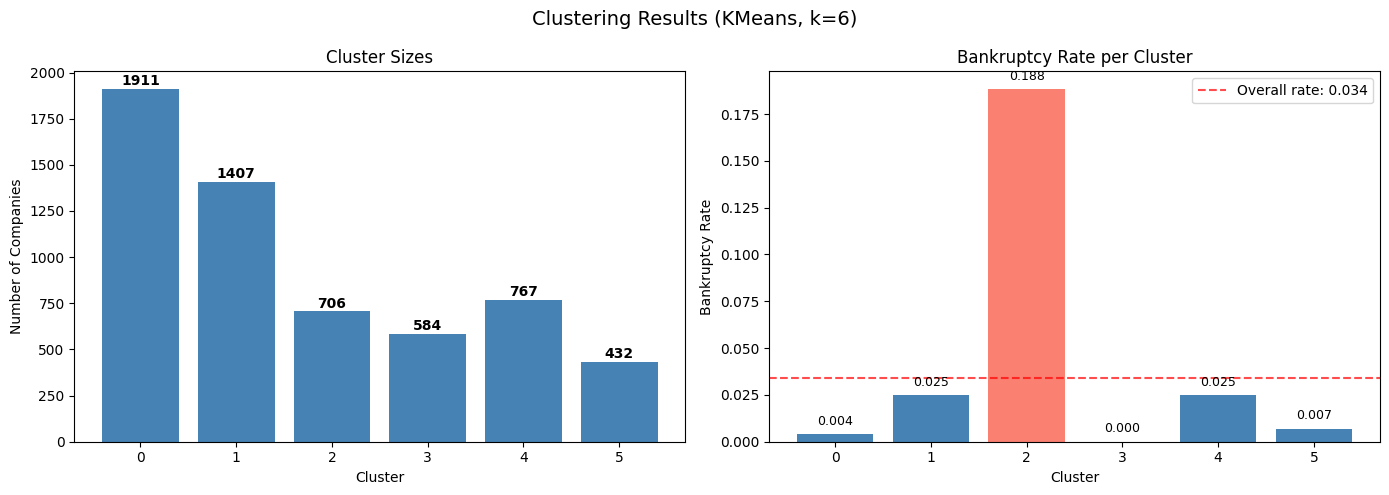

In [22]:
# Cluster distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
axes[0].bar(cluster_counts.index, cluster_counts.values, color='steelblue')
axes[0].set_title('Cluster Sizes')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Companies')
for i, v in zip(cluster_counts.index, cluster_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Bankruptcy rate per cluster
rates = best_df.set_index('Cluster')['Rate']
colors = ['salmon' if r > 0.05 else 'steelblue' for r in rates.values]
axes[1].bar(rates.index, rates.values, color=colors)
axes[1].set_title('Bankruptcy Rate per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Bankruptcy Rate')
axes[1].axhline(y=y_train.mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall rate: {y_train.mean():.3f}')
axes[1].legend()
for i, v in zip(rates.index, rates.values):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle(f'Clustering Results ({best_name}, k={K})', fontsize=14)
plt.tight_layout()
plt.show()

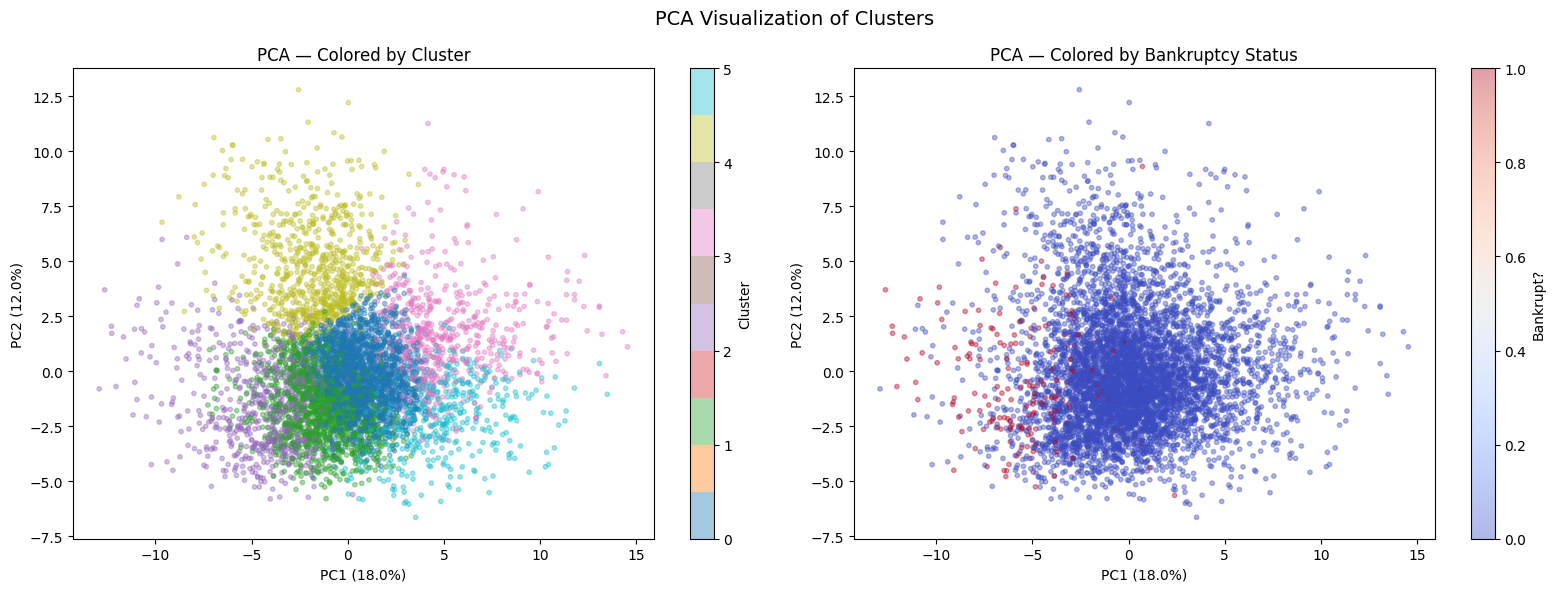

In [23]:
# PCA 2D visualization colored by cluster
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_processed)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.4, s=10)
axes[0].set_title('PCA — Colored by Cluster')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.4, s=10)
axes[1].set_title('PCA — Colored by Bankruptcy Status')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter2, ax=axes[1], label='Bankrupt?')

plt.suptitle('PCA Visualization of Clusters', fontsize=14)
plt.tight_layout()
plt.show()

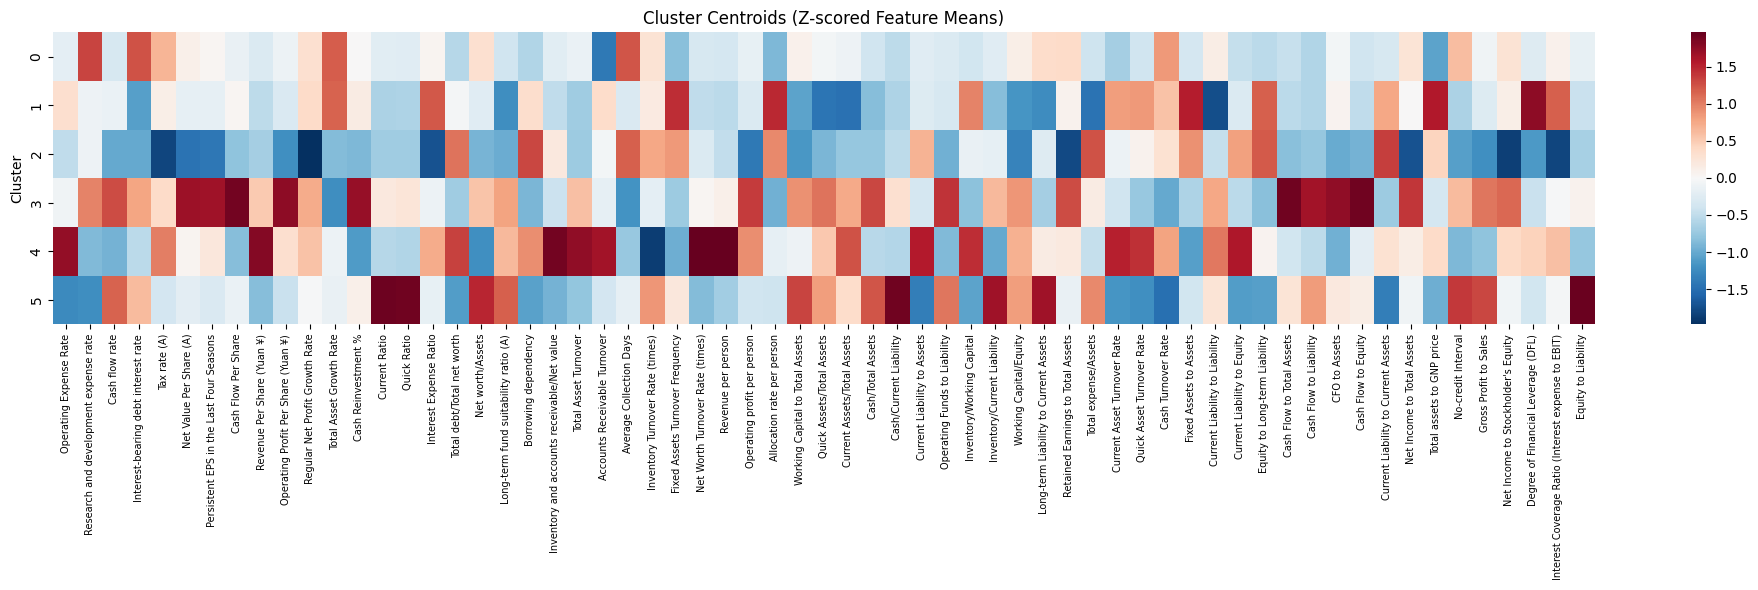

In [24]:
# Cluster centroid heatmap (using original unscaled features for interpretability)
X_unscaled = pipeline._transform_raw(df)
X_unscaled['Cluster'] = cluster_labels

centroids = X_unscaled.groupby('Cluster').mean()

# Normalize centroids for heatmap
centroids_norm = (centroids - centroids.mean()) / centroids.std()

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(centroids_norm, cmap='RdBu_r', center=0, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('Cluster Centroids (Z-scored Feature Means)')
ax.set_ylabel('Cluster')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

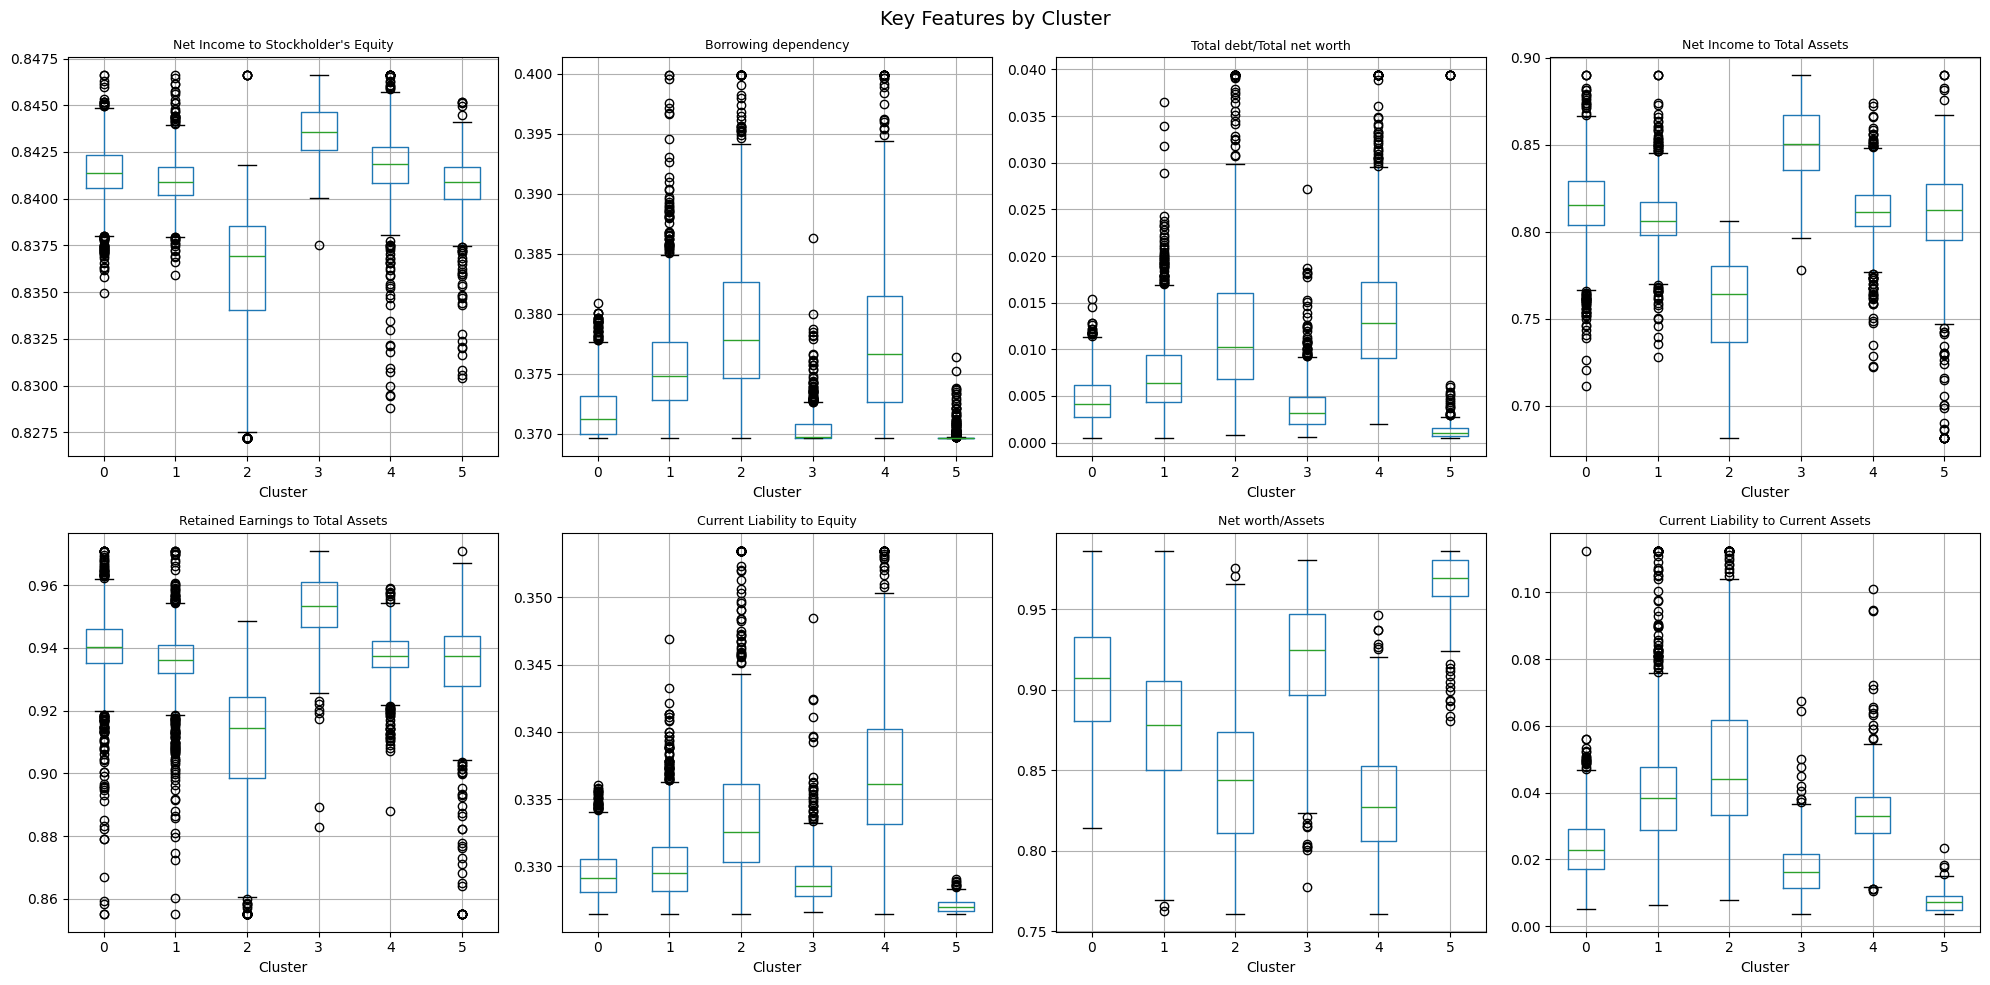

In [25]:
# Box plots of key features per cluster
key_features = target_corr_remaining.head(8).index.tolist()
X_plot = X_unscaled.copy()
X_plot['Bankrupt?'] = y_train.values

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feat in enumerate(key_features):
    ax = axes[i // 4, i % 4]
    X_plot.boxplot(column=feat, by='Cluster', ax=ax)
    ax.set_title(feat[:35], fontsize=9)
    ax.set_xlabel('Cluster')

plt.suptitle('Key Features by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# Detailed cluster characterization
print('=' * 80)
print('CLUSTER CHARACTERIZATION SUMMARY')
print('=' * 80)

X_char = pipeline._transform_raw(df)
X_char['Cluster'] = cluster_labels
X_char['Bankrupt?'] = y_train.values

for c in sorted(set(cluster_labels)):
    mask = cluster_labels == c
    n = mask.sum()
    n_b = y_train[mask].sum()
    rate = n_b / n
    
    print(f'\n--- Cluster {c} ---')
    print(f'  Companies: {n}  |  Bankrupt: {int(n_b)}  |  Rate: {rate:.4f}')
    
    # Find features where this cluster differs most from overall mean
    cluster_means = X_char[mask][pipeline.clustering_features].mean()
    overall_means = X_char[pipeline.clustering_features].mean()
    overall_stds = X_char[pipeline.clustering_features].std()
    z_scores = ((cluster_means - overall_means) / overall_stds).abs().sort_values(ascending=False)
    
    print(f'  Distinguishing features (highest Z-score from overall mean):')
    for feat in z_scores.head(5).index:
        direction = 'HIGH' if cluster_means[feat] > overall_means[feat] else 'LOW'
        print(f'    {feat[:50]:50s}  {direction}  (Z={z_scores[feat]:.2f})')

CLUSTER CHARACTERIZATION SUMMARY

--- Cluster 0 ---
  Companies: 1911  |  Bankrupt: 8  |  Rate: 0.0042
  Distinguishing features (highest Z-score from overall mean):
    Borrowing dependency                                LOW  (Z=0.44)
    Total debt/Total net worth                          LOW  (Z=0.41)
    Current Liability to Current Assets                 LOW  (Z=0.37)
    Net worth/Assets                                    HIGH  (Z=0.37)
    Fixed Assets Turnover Frequency                     LOW  (Z=0.35)

--- Cluster 1 ---
  Companies: 1407  |  Bankrupt: 35  |  Rate: 0.0249
  Distinguishing features (highest Z-score from overall mean):
    Current Assets/Total Assets                         LOW  (Z=0.95)
    Quick Assets/Total Assets                           LOW  (Z=0.89)
    Fixed Assets to Assets                              HIGH  (Z=0.84)
    Working Capital to Total Assets                     LOW  (Z=0.80)
    Current Liability to Liability                      LOW  (Z=0.79

### 3.2.3 — Save Cluster Data

In [27]:
# Save each cluster's original training data to CSV
df_with_cluster = df.copy()
df_with_cluster['Cluster'] = cluster_labels

# Identify constant-prediction clusters
constant_clusters = []
model_clusters = []

for c in sorted(set(cluster_labels)):
    cluster_data = df_with_cluster[df_with_cluster['Cluster'] == c].drop(columns=['Cluster', 'Index'])
    csv_path = os.path.join(CLUSTER_DIR, f'cluster_{c}.csv')
    cluster_data.to_csv(csv_path, index=False)
    
    n_bankrupt = cluster_data['Bankrupt?'].sum()
    n_total = len(cluster_data)
    
    if n_bankrupt == 0 or n_bankrupt == n_total:
        constant_clusters.append(c)
        pred_val = 1 if n_bankrupt == n_total else 0
        print(f'  Cluster {c}: {n_total} companies, {int(n_bankrupt)} bankrupt → CONSTANT prediction (ĥ={pred_val})')
    else:
        model_clusters.append(c)
        print(f'  Cluster {c}: {n_total} companies, {int(n_bankrupt)} bankrupt → needs stacking model')
    print(f'    Saved to {csv_path}')

print(f'\nConstant prediction clusters: {constant_clusters}')
print(f'Clusters needing stacking models: {model_clusters}')

  Cluster 0: 1911 companies, 8 bankrupt → needs stacking model
    Saved to /Users/noahmiller/Documents/CS/CS-559/Project/data/clusters/cluster_0.csv
  Cluster 1: 1407 companies, 35 bankrupt → needs stacking model
    Saved to /Users/noahmiller/Documents/CS/CS-559/Project/data/clusters/cluster_1.csv
  Cluster 2: 706 companies, 133 bankrupt → needs stacking model
    Saved to /Users/noahmiller/Documents/CS/CS-559/Project/data/clusters/cluster_2.csv
  Cluster 3: 584 companies, 0 bankrupt → CONSTANT prediction (ĥ=0)
    Saved to /Users/noahmiller/Documents/CS/CS-559/Project/data/clusters/cluster_3.csv
  Cluster 4: 767 companies, 19 bankrupt → needs stacking model
    Saved to /Users/noahmiller/Documents/CS/CS-559/Project/data/clusters/cluster_4.csv
  Cluster 5: 432 companies, 3 bankrupt → needs stacking model
    Saved to /Users/noahmiller/Documents/CS/CS-559/Project/data/clusters/cluster_5.csv

Constant prediction clusters: [np.int32(3)]
Clusters needing stacking models: [np.int32(0), np

In [30]:
cluster_meta = {
    'n_clusters': K,
    'method': best_name,
    'constant_clusters': constant_clusters,
    'model_clusters': model_clusters,
    'cluster_summary': best_df.to_dict('records'),
    'clustering_features': pipeline.clustering_features,
    'random_state': RANDOM_STATE
}
joblib.dump(cluster_meta, os.path.join(MODEL_DIR, 'cluster_metadata.joblib'))
print('Cluster metadata saved.')

Cluster metadata saved.


---
## Section 3.3.1 — Cluster-ID Prediction Model

In [29]:
# Train a classifier to predict cluster-ID from preprocessed features
# This will be used to assign test companies to clusters

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Try Random Forest and Gradient Boosting
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE, max_depth=5)

rf_scores = cross_val_score(rf, X_processed, cluster_labels, cv=5, scoring='accuracy')
gb_scores = cross_val_score(gb, X_processed, cluster_labels, cv=5, scoring='accuracy')

print(f'Random Forest CV accuracy: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}')
print(f'Gradient Boosting CV accuracy: {gb_scores.mean():.4f} ± {gb_scores.std():.4f}')

Random Forest CV accuracy: 0.8981 ± 0.0117
Gradient Boosting CV accuracy: 0.9161 ± 0.0112


In [31]:
# Select best and fit on full training set
if rf_scores.mean() >= gb_scores.mean():
    best_cluster_model = rf
    print('Selected: Random Forest')
else:
    best_cluster_model = gb
    print('Selected: Gradient Boosting')

best_cluster_model.fit(X_processed, cluster_labels)

# Verify on training data
train_preds = best_cluster_model.predict(X_processed)
train_acc = (train_preds == cluster_labels).mean()
print(f'Training accuracy: {train_acc:.4f}')

Selected: Gradient Boosting
Training accuracy: 1.0000


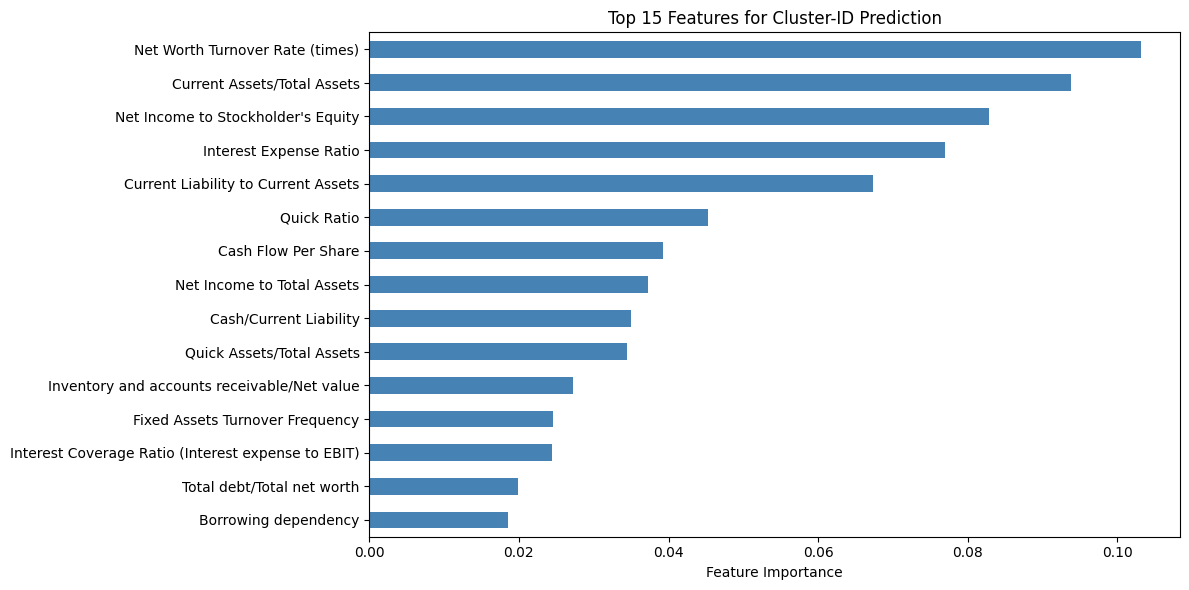

In [33]:
# Feature importance for cluster-ID prediction
if hasattr(best_cluster_model, 'feature_importances_'):
    importances = pd.Series(
        best_cluster_model.feature_importances_,
        index=pipeline.clustering_features
    ).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    importances.head(15).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 15 Features for Cluster-ID Prediction')
    ax.set_xlabel('Feature Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [35]:
# Save the cluster-ID model
cluster_model_path = os.path.join(MODEL_DIR, 'cluster_id_model.joblib')
joblib.dump(best_cluster_model, cluster_model_path)
print(f'Cluster-ID model saved to: {cluster_model_path}')

# Verify
loaded_model = joblib.load(cluster_model_path)
verify_preds = loaded_model.predict(X_processed)
assert np.array_equal(train_preds, verify_preds), 'Model reload verification failed!'
print('Model reload verification passed.')

Cluster-ID model saved to: /Users/noahmiller/Documents/CS/CS-559/Project/models/cluster_id_model.joblib
Model reload verification passed.


## Summary

### Results
- **Preprocessing**: Reduced from 95 features to the selected clustering feature set
- **Clustering**: Used the best method with k=6 subgroups
- **Cluster-ID model**: Trained and saved

### Saved Artifacts
- `models/preprocessing_pipeline.joblib` — Reusable preprocessing pipeline
- `models/cluster_id_model.joblib` — Cluster-ID prediction model  
- `models/cluster_metadata.joblib` — Cluster metadata
- `data/clusters/cluster_{i}.csv` — Per-cluster training data

